In [1]:
import os

import pandas as pd
from tqdm import tqdm

tqdm.pandas()

# 1. Load raw data (SweGymLegacy output.jsonl) and convert to training data

This notebook handles the SweGymLegacy format (`output.jsonl`).
We use the same `load_completions` logic as `combine_final_completions.py`
to extract messages and tools from the `llm_completions/` directory.

In [2]:
import json
import os
from glob import glob

from tqdm import tqdm

FILE_PATHS = [
    '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/SweGymLegacyCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-no-hint-swegym-legacy-train-glm5_fp8_t05/output.jsonl',
]


def load_completions(output_dir: str, instance_id: str):
    """Load completions from llm_completions directory.

    Same logic as combine_final_completions.py:
    pick the last turn's completion file, extract messages + tools.
    """
    glob_path = os.path.join(output_dir, 'llm_completions', instance_id, '*.json')
    files = sorted(glob(glob_path))  # ascending order
    try:
        file_path = files[-1]  # pick the last file (last turn)
    except IndexError:
        return None
    with open(file_path, 'r') as f:
        result = json.load(f)
    # create messages: all messages + the final assistant response
    messages = result['messages']
    messages.append(result['response']['choices'][0]['message'])
    tools = result['kwargs'].get('tools', [])
    return {
        'messages': messages,
        'tools': tools,
    }


# Load and convert
data = []

for FILE_PATH in FILE_PATHS:
    output_dir = os.path.dirname(FILE_PATH)
    with open(FILE_PATH, 'r') as f:
        for i, line in tqdm(
            enumerate(f), desc=f'Processing {FILE_PATH.split("/")[-1]}'
        ):
            raw_data = json.loads(line)
            instance_id = raw_data.get('instance_id', '')
            completions = load_completions(output_dir, instance_id)
            if completions is None:
                continue

            data.append(
                {
                    'instance_id': instance_id,
                    'messages': completions['messages'],
                    'git_patch': raw_data.get('test_result', {}).get('git_patch', ''),
                    'tools': completions['tools'],
                }
            )

df = pd.DataFrame(data)
print(f'#total amount of data={len(df)}')
df = df[~df['messages'].isna()]
print(f'#total amount of data after removing nan={len(df)}')

Processing output.jsonl: 632it [00:42, 14.72it/s]

#total amount of data=602
#total amount of data after removing nan=602


## Filter

In [3]:
def _contains_multiple_tool_calls(messages: list[dict]) -> bool:
    return any(
        message.get('tool_calls') and len(message['tool_calls']) > 1
        for message in messages
    )


df['contains_multiple_tool_calls'] = df['messages'].apply(_contains_multiple_tool_calls)
display(df['contains_multiple_tool_calls'].value_counts())

contains_multiple_tool_calls
False    600
True       2
Name: count, dtype: int64

In [4]:
import copy

# Convert function calling messages to non-function calling messages
from openhands.llm.fn_call_converter import (
    FunctionCallConversionError,
    convert_fncall_messages_to_non_fncall_messages,
    convert_from_multiple_tool_calls_to_single_tool_call_messages,
)

total_failed = 0


def _convert_messages(messages: list[dict], tools: list[dict]) -> list[dict]:
    global total_failed
    message_copy = copy.deepcopy(messages)
    for message in message_copy:
        if message['content'] is None:
            message['content'] = ''
    try:
        return convert_fncall_messages_to_non_fncall_messages(
            message_copy, tools, add_in_context_learning_example=False
        )
    except FunctionCallConversionError:
        total_failed += 1
        return None


df['converted_messages'] = df.apply(
    lambda row: convert_from_multiple_tool_calls_to_single_tool_call_messages(
        row['messages'], ignore_final_tool_result=True
    ),
    axis=1,
)
df['nonfncall_messages'] = df.apply(
    lambda row: _convert_messages(row['converted_messages'], row['tools']), axis=1
)
print('total nan', df['nonfncall_messages'].isna().sum())
df = df[~df['nonfncall_messages'].isna()]
print(f'Total failed: {total_failed}')

total nan 0
Total failed: 0


## Tokenization

In [5]:
from pandarallel import pandarallel
from transformers import AutoTokenizer

os.environ['TOKENIZERS_PARALLELISM'] = 'true'
pandarallel.initialize(progress_bar=True, verbose=1, nb_workers=16)
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')


def _normalize_and_tokenize(messages):
    normalized = []
    for msg in messages:
        m = dict(msg)
        if isinstance(m.get('content'), list):
            m['content'] = '\n'.join(
                part['text'] for part in m['content'] if part.get('type') == 'text'
            )
        normalized.append(m)
    return len(tokenizer.apply_chat_template(normalized))


df['n_tokens'] = df['nonfncall_messages'].parallel_apply(_normalize_and_tokenize)

In [6]:
print(f'BEFORE: #total={len(df)}')
df_selected = df[df['n_tokens'] < 131072]
print(f'AFTER(truncated to 128k): #total={len(df_selected)}')

BEFORE: #total=602
AFTER(truncated to 128k): #total=602


In [7]:
df_selected['n_tokens'].describe()

count       602.000000
mean      60458.470100
std       12615.337285
min       22559.000000
25%       53342.750000
50%       60046.000000
75%       67390.250000
max      111578.000000
Name: n_tokens, dtype: float64

count       602.000000
mean      60458.470100
std       12615.337285
min       22559.000000
25%       53342.750000
50%       60046.000000
75%       67390.250000
max      111578.000000
Name: n_tokens, dtype: float64

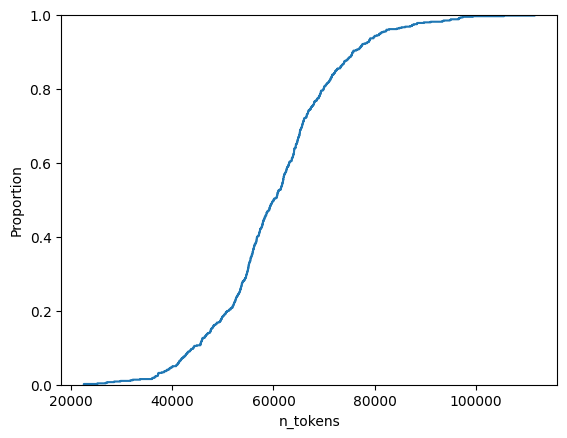

#total=602
#selected=602


count       602.000000
mean      60458.470100
std       12615.337285
min       22559.000000
25%       53342.750000
50%       60046.000000
75%       67390.250000
max      111578.000000
Name: n_tokens, dtype: float64

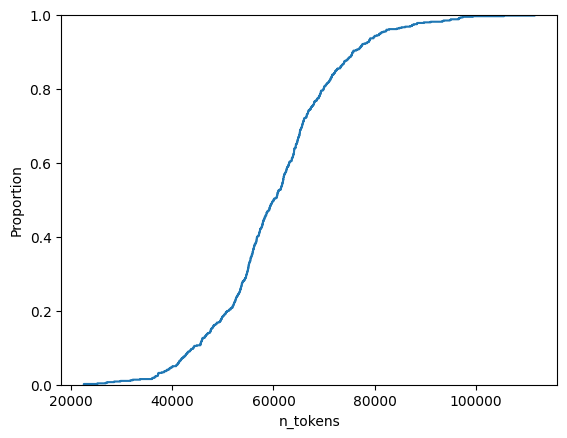

In [8]:
# ecdf of n_tokens
import matplotlib.pyplot as plt
import seaborn as sns

display(df['n_tokens'].describe())
sns.ecdfplot(x='n_tokens', data=df)
plt.show()

print(f'#total={len(df)}')
df_selected = df[df['n_tokens'] < 131072]
print(f'#selected={len(df_selected)}')
display(df_selected['n_tokens'].describe())
sns.ecdfplot(x='n_tokens', data=df_selected)
plt.show()

In [ ]:
df_selected['n_tokens'].describe()

In [ ]:
def _normalize_to_sft_format(messages):
    """Convert messages to SWE-Gym/OpenHands-SFT-Trajectories format.

    Target: each message has only 'role' (str) and 'content' (str).
    """
    normalized = []
    for msg in messages:
        content = msg.get('content', '') or ''
        if isinstance(content, list):
            content = '\n'.join(
                part['text'] for part in content if part.get('type') == 'text'
            )
        normalized.append({'role': msg['role'], 'content': content})
    return normalized


df_selected = df_selected.copy()
df_selected['nonfncall_messages'] = df_selected['nonfncall_messages'].apply(_normalize_to_sft_format)
print('Normalized messages to SFT format (role + content strings only)')

# Save Messages for SFT

Note: No resolved/unresolved filtering since this data does not contain eval results.

In [ ]:
save_dir = '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/SweGymLegacyCodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-no-hint-swegym-legacy-train-glm5_fp8_t05/sft'

if os.path.exists(save_dir):
    print(f'{save_dir} already exists, skipping saving.')
else:
    os.makedirs(save_dir, exist_ok=True)

df_selected[['nonfncall_messages']].rename(
    columns={'nonfncall_messages': 'messages'}
).to_json(
    os.path.join(
        save_dir,
        f'policy_traj_128k_swegym_all_{len(df_selected)}i.jsonl',
    ),
    lines=True,
    orient='records',
)
print(f'Saved {len(df_selected)} trajectories to {save_dir}')